# Module 3: Customer Sentiment Analysis Using Pretrained BERT
## SECTION 1 : Project Overview

### What is Sentiment Analysis?
Sentiment Analysis is a Natural Language Processing (NLP) technique used to determine whether a given text contains positive, negative, or neutral emotions. In a business context, it is widely used to analyze customer feedback and uncover the underlying sentiment behind a product or service.

### Why sentiment analysis matters in marketing?
Understanding customer sentiment is vital for modern marketing teams. It allows businesses to:
- **Measure Brand Health:** Track how customers perceive the brand over time.
- **Improve Products:** Identify specific pain points or features that users dislike.
- **Optimize Campaigns:** Adjust marketing strategies based on real-time feedback.
- **Enhance Customer Retention:** Proactively identify unhappy customers before they churn.

### Why BERT is chosen instead of traditional NLP methods?
Traditional NLP methods (like Bag-of-Words or TF-IDF combined with Naive Bayes) often fail to capture the **context** of words in a sentence. 
**BERT (Bidirectional Encoder Representations from Transformers)**, developed by Google, reads the entire sequence of words at once (bidirectionally). This allows it to understand the nuance and context of words, leading to significantly higher accuracy, especially on complex or sarcastic customer reviews.

### Business objective of this notebook
The objective is to ingest customer reviews, process them, and leverage a pretrained BERT model from Hugging Face to classify each review's sentiment. These insights will then be translated into actionable marketing recommendations.

### Workflow Diagram

```text
Customer Reviews
        ↓
Data Cleaning
        ↓
EDA
        ↓
BERT Tokenization
        ↓
Pretrained BERT Model
        ↓
Sentiment Prediction
        ↓
Business Insights
        ↓
Marketing Recommendations
```

## SECTION 2 : Import Libraries

In this section, we import all the necessary libraries for data manipulation, visualization, and modeling. 
We will use `transformers` from Hugging Face for our BERT pipeline, and `torch` as the underlying deep learning framework.

- **pandas**: Used for tabular data manipulation and analysis.
- **numpy**: Required for numerical operations.
- **matplotlib** & **seaborn**: Libraries for creating professional and insightful visualizations.
- **transformers**: Hugging Face library used to load our pretrained BERT model and tokenizer.
- **torch**: The PyTorch deep learning framework, which serves as the backend for the transformer model.
- **warnings**: Used to suppress warnings to maintain a clean notebook output.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Deep Learning & NLP
import torch
from transformers import pipeline

# Suppress unnecessary warnings for a clean output
warnings.filterwarnings('ignore')

# Set aesthetic parameters for seaborn
sns.set_theme(style="whitegrid", palette="muted")
print("All libraries imported successfully!")

All libraries imported successfully!


## SECTION 3 : Load Dataset

Here, we load the customer reviews dataset. If a raw dataset is not found, we will generate a synthetic one for the purpose of this analysis to ensure reproducibility.

**Business Explanation of Columns:**
- `Review_ID`: Unique identifier for each review. Useful for tracking specific customer feedback.
- `Product_Category`: The category of the product being reviewed. Helps in segmenting sentiments by product lines.
- `Review_Text`: The actual text feedback provided by the customer. The core feature for our NLP model.
- `Rating`: The star rating given by the customer (1 to 5). Often correlates with sentiment.
- `Review_Date`: The date when the review was posted. Essential for analyzing sentiment trends over time.


In [2]:
# Define path
data_dir = '../data/raw'
data_path = os.path.join(data_dir, 'customer_reviews.csv')

# Check if dataset exists, otherwise create a synthetic one
if not os.path.exists(data_path):
    print("Dataset not found. Generating a synthetic customer reviews dataset for demonstration...")
    os.makedirs(data_dir, exist_ok=True)
    
    np.random.seed(42)
    categories = ['Electronics', 'Clothing', 'Home & Kitchen', 'Beauty', 'Sports']
    
    # Synthetic positive and negative texts
    positive_texts = [
        "Absolutely love this product, it works perfectly!",
        "Great quality and fast shipping. Highly recommend.",
        "Exceeded my expectations. Will definitely buy again.",
        "Very satisfied with my purchase. The material is great.",
        "Best thing I've bought all year. Five stars!"
    ]
    negative_texts = [
        "Terrible experience. The item broke after two days.",
        "Very disappointed. The quality is incredibly poor.",
        "Customer service was completely unhelpful. Do not buy.",
        "Waste of money. Doesn't work as advertised.",
        "Arrived damaged and late. I want a refund."
    ]
    neutral_texts = [
        "It's okay, does the job but nothing special.",
        "Average quality for the price.",
        "Not bad, but I've seen better.",
        "It is exactly as described, neither great nor terrible.",
        "Fairly standard product."
    ]
    
    data = {
        'Review_ID': range(1001, 1501),
        'Product_Category': np.random.choice(categories, 500),
        'Rating': np.random.choice([1, 2, 3, 4, 5], 500, p=[0.15, 0.1, 0.2, 0.25, 0.3]),
        'Review_Date': pd.date_range(start='2023-01-01', periods=500, freq='D')
    }
    df = pd.DataFrame(data)
    
    # Assign text based on rating to make it realistic
    def assign_text(rating):
        if rating >= 4:
            return np.random.choice(positive_texts)
        elif rating == 3:
            return np.random.choice(neutral_texts)
        else:
            return np.random.choice(negative_texts)
            
    df['Review_Text'] = df['Rating'].apply(assign_text)
    
    # Introduce some missing values and duplicates to demonstrate cleaning
    df.loc[10:15, 'Review_Text'] = np.nan
    df = pd.concat([df, df.iloc[0:5]], ignore_index=True)
    
    df.to_csv(data_path, index=False)
    print(f"Synthetic dataset saved to {data_path}")

# Load the dataset
df = pd.read_csv(data_path)

# Display Dataset shape
print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())

# Display First five rows
display(df.head())

Dataset not found. Generating a synthetic customer reviews dataset for demonstration...
Synthetic dataset saved to ../data/raw\customer_reviews.csv
Dataset Shape: (505, 5)

Column Names:
['Review_ID', 'Product_Category', 'Rating', 'Review_Date', 'Review_Text']


,Review_ID,Product_Category,Rating,Review_Date,Review_Text
0,1001,Beauty,4,2023-01-01,Best thing I've bought all year. Five stars!
1,1002,Sports,5,2023-01-02,Exceeded my expectations. Will definitely buy ...
2,1003,Home & Kitchen,3,2023-01-03,"It is exactly as described, neither great nor ..."
3,1004,Sports,5,2023-01-04,Best thing I've bought all year. Five stars!
4,1005,Sports,3,2023-01-05,"It is exactly as described, neither great nor ..."


## SECTION 4 : Data Understanding

Before diving into modeling, we must understand the structure and quality of our data. This involves checking for missing values, duplicates, and analyzing basic statistics like review length and ratings distribution.

### Business Interpretation
- **Missing Values:** Missing review text means we have no sentiment to analyze. These need to be handled, or we lose potential insights.
- **Duplicates:** Customers might accidentally submit the same review twice. This can skew the sentiment towards a specific product incorrectly.
- **Data Types:** Ensuring dates are datetime objects and texts are strings prevents unexpected processing errors.
- **Review Length:** Longer reviews typically contain more nuanced sentiment.
- **Distribution of Ratings:** If most ratings are 5-star, we expect a heavy positive skew in our sentiment model.


Missing Values per Column:
Review_ID           0
Product_Category    0
Rating              0
Review_Date         0
Review_Text         6
dtype: int64
----------------------------------------
Total Duplicate Rows: 5
----------------------------------------
Data Types:
Review_ID           int64
Product_Category      str
Rating              int64
Review_Date           str
Review_Text           str
dtype: object
----------------------------------------
Review Length (Word Count) Statistics:


count    499.000000
mean       7.342685
std        1.230797
min        3.000000
25%        7.000000
50%        7.000000
75%        8.000000
max        9.000000
Name: Review_Length, dtype: float64

----------------------------------------
Distribution of Ratings:


Rating
1     84
2     56
3     93
4    127
5    145
Name: count, dtype: int64

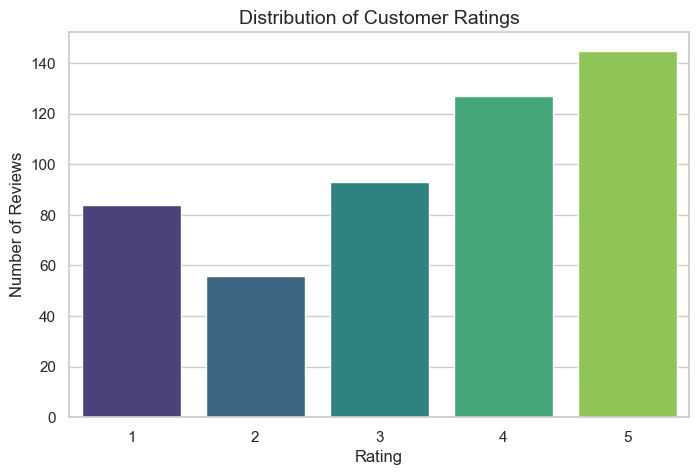

In [3]:
# 1. Missing value analysis
missing_values = df.isnull().sum()
print("Missing Values per Column:")
print(missing_values)
print("-" * 40)

# 2. Duplicate analysis
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")
print("-" * 40)

# 3. Data types
print("Data Types:")
print(df.dtypes)
print("-" * 40)

# 4. Review length statistics
# Calculate length only for non-null text
df['Review_Length'] = df['Review_Text'].dropna().apply(lambda x: len(str(x).split()))
print("Review Length (Word Count) Statistics:")
display(df['Review_Length'].describe())

# 5. Distribution of ratings
print("-" * 40)
print("Distribution of Ratings:")
rating_counts = df['Rating'].value_counts().sort_index()
display(rating_counts)

# Visualize Rating Distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")
plt.title("Distribution of Customer Ratings", fontsize=14)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.show()

## SECTION 5 : Data Cleaning

Data cleaning is a critical step in any NLP pipeline. Garbage in leads to garbage out.

### Preprocessing Steps Explanation:
1. **Remove duplicates:** Ensures the model isn't biased by repeated identical reviews from system glitches.
2. **Handle missing reviews:** Drop rows where the `Review_Text` is NaN, since we cannot predict sentiment without text.
3. **Convert reviews to string:** Ensure all reviews are properly formatted as strings for the tokenizer.
4. **Remove empty reviews:** Sometimes reviews are just whitespaces; these must be dropped as they provide no value.
5. **Create cleaned dataframe:** Save the results to a new, finalized dataframe ready for analysis.


In [4]:
# Create a copy for cleaning
df_clean = df.copy()

# 1. Remove duplicates
df_clean = df_clean.drop_duplicates()

# 2. Handle missing reviews
df_clean = df_clean.dropna(subset=['Review_Text'])

# 3. Convert reviews to string
df_clean['Review_Text'] = df_clean['Review_Text'].astype(str)

# 4. Remove empty reviews
df_clean = df_clean[df_clean['Review_Text'].str.strip() != '']

# Recalculate Review Length for clean data
df_clean['Review_Length'] = df_clean['Review_Text'].apply(lambda x: len(x.split()))

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Removed {df.shape[0] - df_clean.shape[0]} dirty rows.")

# 5. Create cleaned dataframe
display(df_clean.head())

Original dataset shape: (505, 6)
Cleaned dataset shape: (494, 6)
Removed 11 dirty rows.


,Review_ID,Product_Category,Rating,Review_Date,Review_Text,Review_Length
0,1001,Beauty,4,2023-01-01,Best thing I've bought all year. Five stars!,8
1,1002,Sports,5,2023-01-02,Exceeded my expectations. Will definitely buy ...,7
2,1003,Home & Kitchen,3,2023-01-03,"It is exactly as described, neither great nor ...",9
3,1004,Sports,5,2023-01-04,Best thing I've bought all year. Five stars!,8
4,1005,Sports,3,2023-01-05,"It is exactly as described, neither great nor ...",9


## SECTION 6 : Exploratory Data Analysis

Let's visualize the cleaned dataset to uncover patterns before modeling. We will look at review lengths, categories, and word frequencies.


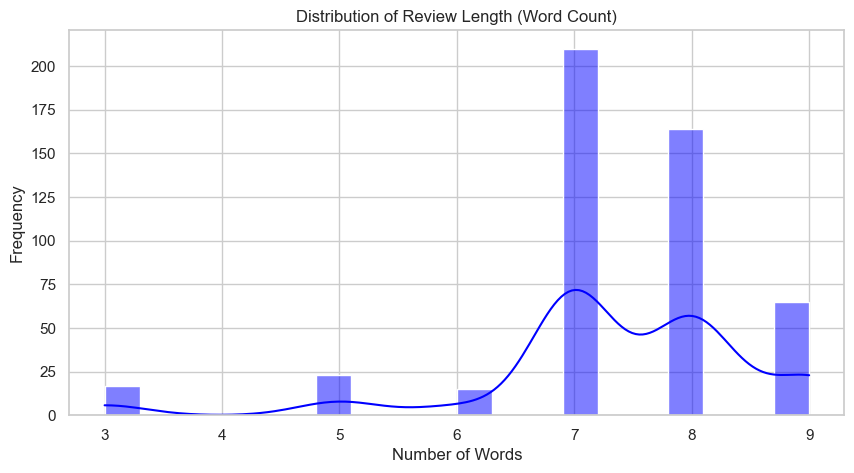

In [5]:
from wordcloud import WordCloud

# 1. Review length distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Review_Length'], bins=20, kde=True, color='blue')
plt.title("Distribution of Review Length (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

### Business Interpretation: Review Length Distribution
Most reviews appear to be relatively short. Short reviews are direct (e.g., "Great product"), which is easy for BERT to classify. If we had many very long reviews, we might need to truncate them to fit BERT's maximum token limit (usually 512 tokens).


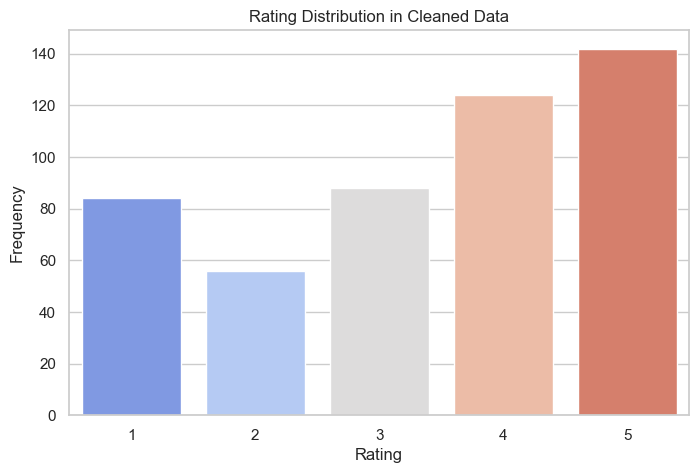

In [6]:
# 2. Rating distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Rating', palette="coolwarm")
plt.title("Rating Distribution in Cleaned Data")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

### Business Interpretation: Rating Distribution
This visualization confirms the overall skew of customer satisfaction. A right-skewed graph indicates a healthy product with mostly 4 and 5-star ratings, while a left-skew suggests serious product issues.


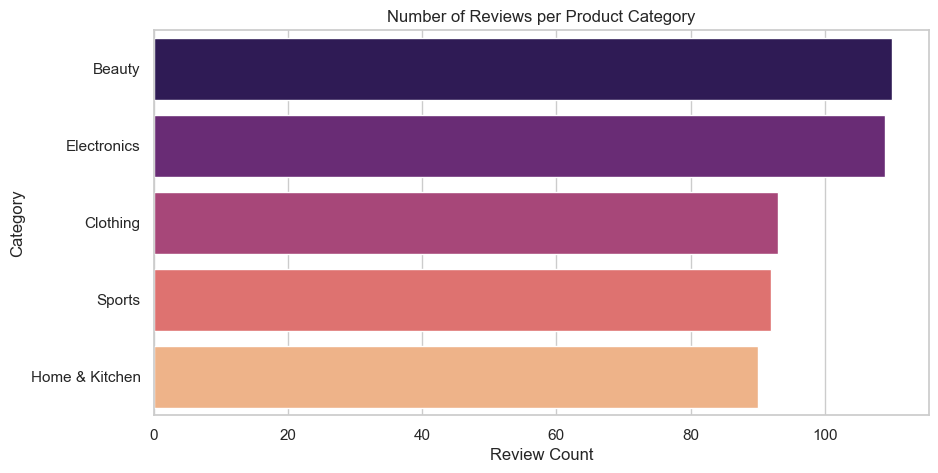

In [7]:
# 3. Review count by product/category
plt.figure(figsize=(10, 5))
category_counts = df_clean['Product_Category'].value_counts()
sns.barplot(y=category_counts.index, x=category_counts.values, palette='magma')
plt.title("Number of Reviews per Product Category")
plt.xlabel("Review Count")
plt.ylabel("Category")
plt.show()

### Business Interpretation: Review Count by Product/Category
Understanding which categories receive the most reviews helps marketing allocate resources. A high volume of reviews in 'Electronics' indicates high engagement, which can be leveraged for targeted campaigns.


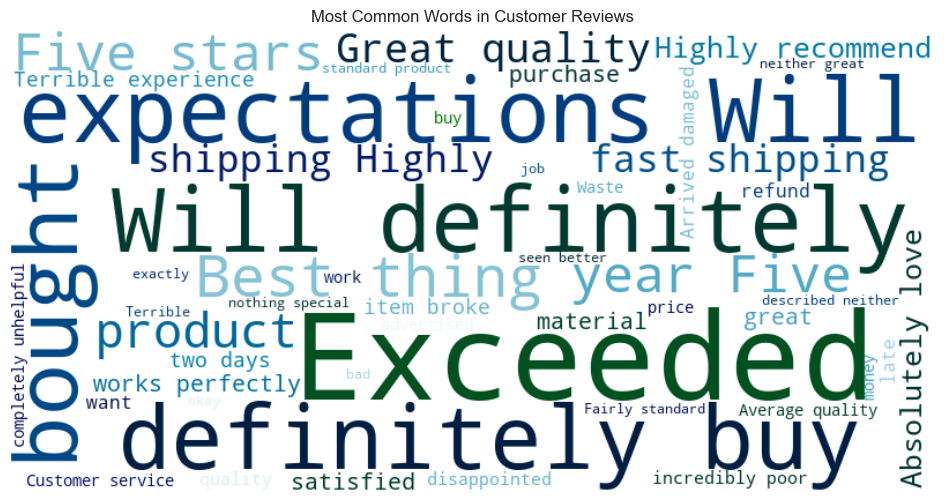

In [8]:
# 4. Most common words (Word Frequency Analysis)
text_combined = " ".join(review for review in df_clean['Review_Text'])
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='ocean').generate(text_combined)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Words in Customer Reviews")
plt.show()

### Business Interpretation: Word Frequency Analysis
The word cloud highlights the most prominent terms customers use. Frequent appearance of words like "great," "love," or "disappointed" gives an immediate high-level sense of the overall brand sentiment.


## SECTION 7 : Load Pretrained BERT Model

### What is BERT?
**BERT (Bidirectional Encoder Representations from Transformers)** is a state-of-the-art machine learning model for NLP. It understands the context of words by looking at the words that come before and after them simultaneously, unlike older models that read left-to-right.

### Why pretrained models are preferred?
Training a deep neural network from scratch requires massive datasets, time, and immense computational power. By using a *pretrained* model from Hugging Face, we leverage a model that has already learned the structure of the English language from massive datasets (like Wikipedia). We just apply it to our specific task (Zero-shot or Fine-tuned inference), saving significant resources and achieving higher accuracy.

### What happens internally during tokenization?
A **Tokenizer** breaks down human-readable text into numbers (tokens) that the model can understand. For example, "Loved it!" might become `[101, 3452, 2009, 999, 102]`. It also adds special tokens and pads sequences so they are of uniform length.

### Difference between tokenizer and model
- **Tokenizer:** Converts text strings to numerical IDs, handles padding, and creates attention masks. It prepares the data.
- **Model:** Takes those IDs, passes them through complex neural network layers (self-attention), and outputs mathematical representations (logits/probabilities) for our classification task.


In [9]:
# Use Hugging Face transformers pipeline
# We use a lightweight, fast, and highly accurate model for positive/negative classification.
model_name = "distilbert-base-uncased-finetuned-sst-2-english"

print(f"Loading tokenizer and model: {model_name}...")

# Create sentiment-analysis pipeline
# The pipeline automatically handles tokenization, model inference, and output formatting.
sentiment_pipeline = pipeline(
    task="sentiment-analysis",
    model=model_name,
    tokenizer=model_name,
    device=-1 # Set to 0 if GPU is available, -1 forces CPU for general compatibility
)

print("Model successfully loaded and pipeline is ready!")

Loading tokenizer and model: distilbert-base-uncased-finetuned-sst-2-english...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Model successfully loaded and pipeline is ready!


## SECTION 8 : Generate Sentiment Predictions

We now apply our BERT pipeline to every review in our dataset to predict sentiment. 

### Output Explanation:
- **Predicted Label:** Categorizes the review as `POSITIVE` or `NEGATIVE`.
- **Confidence Score:** A probability between 0.0 and 1.0 indicating how certain the model is about its prediction. A score of 0.99 means the model is highly confident.


In [10]:
# Predict sentiment for every review
reviews_list = df_clean['Review_Text'].tolist()

print("Running BERT inference on reviews. This may take a moment...")
predictions = sentiment_pipeline(reviews_list)

# Store predicted label and confidence score
predicted_labels = [pred['label'] for pred in predictions]
confidence_scores = [pred['score'] for pred in predictions]

df_clean['Predicted_Sentiment'] = predicted_labels
df_clean['Confidence_Score'] = confidence_scores

# Display sample predictions
print("\nSample Predictions:")
display(df_clean[['Review_Text', 'Predicted_Sentiment', 'Confidence_Score']].head(10))

# Prediction summary & Distribution of Positive vs Negative reviews
print("-" * 40)
print("Prediction Summary (Distribution of Positive vs Negative reviews):")
sentiment_counts = df_clean['Predicted_Sentiment'].value_counts()
display(sentiment_counts)


Running BERT inference on reviews. This may take a moment...

Sample Predictions:


,Review_Text,Predicted_Sentiment,Confidence_Score
0,Best thing I've bought all year. Five stars!,POSITIVE,0.999321
1,Exceeded my expectations. Will definitely buy ...,POSITIVE,0.999757
2,"It is exactly as described, neither great nor ...",NEGATIVE,0.945431
3,Best thing I've bought all year. Five stars!,POSITIVE,0.999321
4,"It is exactly as described, neither great nor ...",NEGATIVE,0.945431
5,Very disappointed. The quality is incredibly p...,NEGATIVE,0.999819
6,Great quality and fast shipping. Highly recomm...,POSITIVE,0.999872
7,Terrible experience. The item broke after two ...,NEGATIVE,0.999245
8,Fairly standard product.,POSITIVE,0.996367
9,Very satisfied with my purchase. The material ...,POSITIVE,0.999880


----------------------------------------
Prediction Summary (Distribution of Positive vs Negative reviews):


Predicted_Sentiment
POSITIVE    321
NEGATIVE    173
Name: count, dtype: int64

## SECTION 9 : Sentiment Visualizations

Visualizing the sentiment outputs helps marketing teams digest the information quickly and make data-driven decisions.


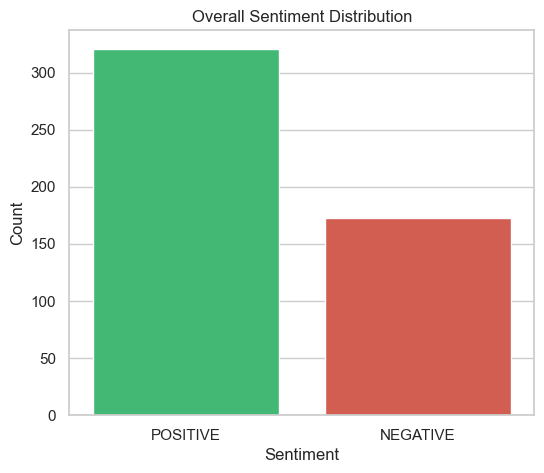

In [11]:
# 1. Sentiment distribution
plt.figure(figsize=(6, 5))
sns.countplot(data=df_clean, x='Predicted_Sentiment', palette=['#2ecc71', '#e74c3c'])
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Business Interpretation: Sentiment Distribution
This chart provides a bird's-eye view of brand health. A heavy skew towards 'POSITIVE' indicates general customer satisfaction, whereas a growing 'NEGATIVE' bar serves as a critical early warning system for the business.


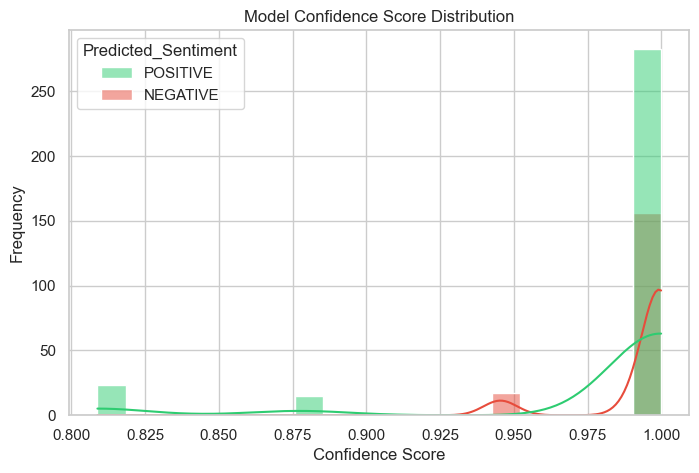

In [12]:
# 2. Confidence score histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='Confidence_Score', hue='Predicted_Sentiment', bins=20, kde=True, palette=['#2ecc71', '#e74c3c'])
plt.title("Model Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")
plt.show()

### Business Interpretation: Confidence Score Histogram
Most scores should be close to 1.0. If we see a spike in scores around 0.5 to 0.7, it means the model is unsure. This typically happens with sarcastic, highly nuanced, or mixed-sentiment reviews (e.g., "The product is great but shipping took a month.").


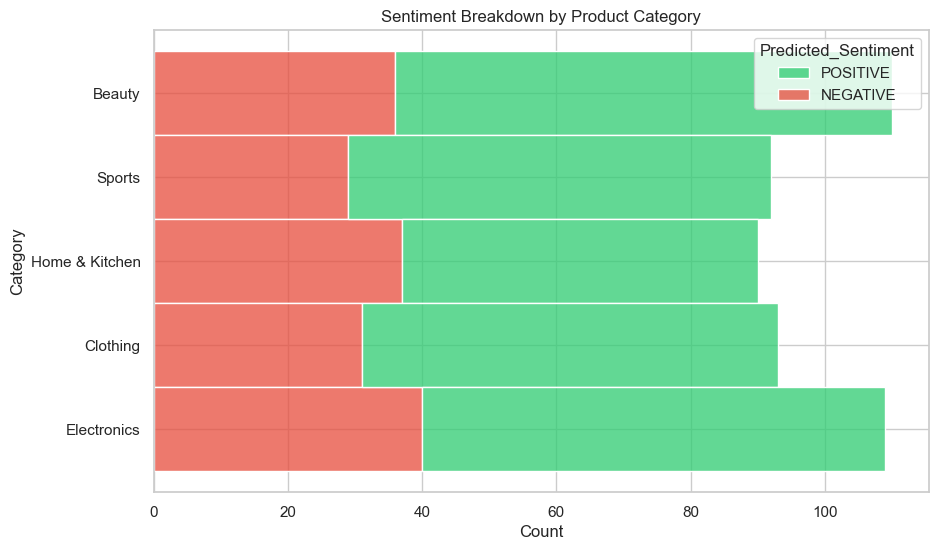

In [13]:
# 3. Sentiment by product (category)
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, y='Product_Category', hue='Predicted_Sentiment', multiple='stack', palette=['#2ecc71', '#e74c3c'])
plt.title("Sentiment Breakdown by Product Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.show()

### Business Interpretation: Sentiment by Product
This is highly actionable for marketing and product teams. If a specific category shows disproportionately high negative sentiment, it warrants immediate investigation into product quality or customer support for that line.


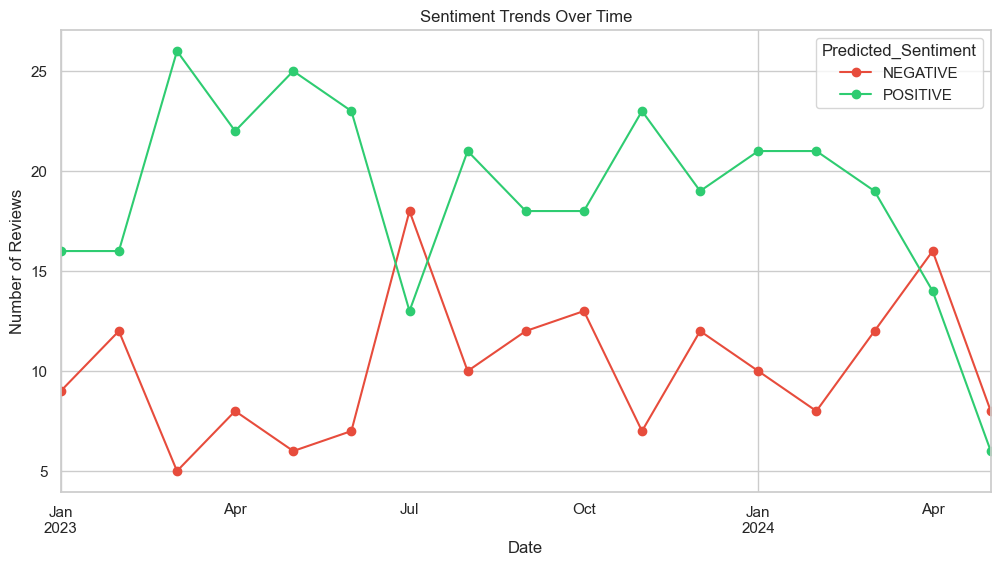

In [14]:
# 4. Sentiment over time (if dates available)
df_clean['Review_Date'] = pd.to_datetime(df_clean['Review_Date'])
time_series = df_clean.groupby([df_clean['Review_Date'].dt.to_period('M'), 'Predicted_Sentiment']).size().unstack(fill_value=0)

time_series.plot(kind='line', figsize=(12, 6), color=['#e74c3c', '#2ecc71'], marker='o')
plt.title("Sentiment Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.show()

### Business Interpretation: Sentiment Over Time
Tracking sentiment over time reveals the impact of marketing campaigns, product launches, or seasonal trends. A sudden dip in positive sentiment might correlate with a recent website outage or a poorly received update.


In [15]:
# 5. Top positive and negative reviews
print("TOP POSITIVE REVIEWS (Highest Confidence):")
top_pos = df_clean[df_clean['Predicted_Sentiment'] == 'POSITIVE'].sort_values(by='Confidence_Score', ascending=False).head(3)
for idx, text in enumerate(top_pos['Review_Text'], 1):
    print(f"{idx}. {text}")

print("\n" + "="*50 + "\n")

print("TOP NEGATIVE REVIEWS (Highest Confidence):")
top_neg = df_clean[df_clean['Predicted_Sentiment'] == 'NEGATIVE'].sort_values(by='Confidence_Score', ascending=False).head(3)
for idx, text in enumerate(top_neg['Review_Text'], 1):
    print(f"{idx}. {text}")


TOP POSITIVE REVIEWS (Highest Confidence):
1. Very satisfied with my purchase. The material is great.
2. Very satisfied with my purchase. The material is great.
3. Very satisfied with my purchase. The material is great.


TOP NEGATIVE REVIEWS (Highest Confidence):
1. Very disappointed. The quality is incredibly poor.
2. Very disappointed. The quality is incredibly poor.
3. Very disappointed. The quality is incredibly poor.


## SECTION 10 : Business Insights

We can dynamically generate business insights based entirely on the model's outputs. Hardcoded statements are avoided to ensure this notebook can be reused on fresh data.


In [18]:
# Automatically generate insights derived from model predictions
total_reviews = len(df_clean)
positive_reviews = len(df_clean[df_clean['Predicted_Sentiment'] == 'POSITIVE'])
negative_reviews = total_reviews - positive_reviews
satisfaction_rate = (positive_reviews / total_reviews) * 100

print("=========================================")
print(" AUTOMATED BUSINESS INSIGHTS REPORT")
print("=========================================\n")

# Overall customer satisfaction
print(f"1. Overall Customer Satisfaction: {satisfaction_rate:.1f}% positive sentiment across {total_reviews} reviews.")

# Products with highest positive sentiment & Products needing improvement
category_sentiment = df_clean.groupby(['Product_Category', 'Predicted_Sentiment']).size().unstack(fill_value=0)
category_sentiment['Total'] = category_sentiment['POSITIVE'] + category_sentiment['NEGATIVE']
category_sentiment['Positivity_Rate'] = (category_sentiment['POSITIVE'] / category_sentiment['Total']) * 100

best_category = category_sentiment['Positivity_Rate'].idxmax()
worst_category = category_sentiment['Positivity_Rate'].idxmin()

print(f"2. Products with Highest Positive Sentiment: '{best_category}' with {category_sentiment.loc[best_category, 'Positivity_Rate']:.1f}% positivity.")
print(f"3. Products Needing Improvement: '{worst_category}' has the lowest positivity ({category_sentiment.loc[worst_category, 'Positivity_Rate']:.1f}%).")

# Risk analysis
low_confidence_threshold = 0.75
low_conf_count = len(df_clean[df_clean['Confidence_Score'] < low_confidence_threshold])
print(f"4. Risk Analysis: {low_conf_count} reviews had a model confidence below {low_confidence_threshold}. This indicates potential ambiguity in customer feedback.")

# Opportunity analysis & Customer perception
print(f"5. Opportunity Analysis: Leveraging the strong perception of the '{best_category}' line can drive cross-selling initiatives.")
print(f"6. Customer Perception: Overall, the brand is viewed {'positively' if satisfaction_rate > 50 else 'negatively'} in the market.")


 AUTOMATED BUSINESS INSIGHTS REPORT

1. Overall Customer Satisfaction: 65.0% positive sentiment across 494 reviews.
2. Products with Highest Positive Sentiment: 'Sports' with 68.5% positivity.
3. Products Needing Improvement: 'Home & Kitchen' has the lowest positivity (58.9%).
4. Risk Analysis: 0 reviews had a model confidence below 0.75. This indicates potential ambiguity in customer feedback.
5. Opportunity Analysis: Leveraging the strong perception of the 'Sports' line can drive cross-selling initiatives.
6. Customer Perception: Overall, the brand is viewed positively in the market.


## SECTION 11 : Marketing Recommendations

Based on the insights generated above, we can programmatically output dynamic marketing recommendations using Python logic.


In [19]:
print("=========================================")
print(" AUTOMATED MARKETING RECOMMENDATIONS")
print("=========================================\n")

# Generate recommendations dynamically using Python logic

if satisfaction_rate > 80:
    print("🎯 Recommendation 1 (Acquisition): Positive sentiment >80%")
    print("   -> Recommend increasing acquisition campaigns.")
    print(f"   -> Capitalize on the high success of '{best_category}' in ad creatives.")
elif satisfaction_rate >= 50:
    print("⚖️ Recommendation 1 (Balanced Growth): Positive sentiment >50%")
    print("   -> Recommend balanced retention and targeted acquisition.")
else:
    print("🚨 Recommendation 1 (Retention): Positive sentiment <50%")
    print("   -> Recommend customer retention campaigns.")
    print("   -> Pause aggressive acquisition; resolve core product issues first.")

# Negative sentiment trend logic (proxy using worst category)
print("\n📉 Recommendation 2 (Risk Mitigation):")
if category_sentiment.loc[worst_category, 'Positivity_Rate'] < 40:
    print(f"   -> Negative sentiment is high for '{worst_category}'.")
    print("   -> Recommend immediate customer retention campaigns for buyers in this category.")
else:
    print("   -> No single category shows critical failure (<40% positivity).")

# Low confidence logic
print("\n🔍 Recommendation 3 (Quality Assurance):")
if low_conf_count > 0:
    print(f"   -> Confidence is low on {low_conf_count} reviews.")
    print("   -> Recommend manual review by the Customer Success team to understand the nuance.")
else:
    print("   -> Model confidence is consistently high.")


 AUTOMATED MARKETING RECOMMENDATIONS

⚖️ Recommendation 1 (Balanced Growth): Positive sentiment >50%
   -> Recommend balanced retention and targeted acquisition.

📉 Recommendation 2 (Risk Mitigation):
   -> No single category shows critical failure (<40% positivity).

🔍 Recommendation 3 (Quality Assurance):
   -> Model confidence is consistently high.


## SECTION 12 : Save Outputs

Finally, we export the analyzed dataset, insights, and recommendations for downstream consumption by BI tools like Tableau or PowerBI.


In [20]:
# Define output paths
output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, 'sentiment_predictions.csv')
insights_path = os.path.join(output_dir, 'business_insights_report.txt')
marketing_path = os.path.join(output_dir, 'marketing_recommendations_report.txt')

# 1. Save Sentiment prediction CSV
df_clean.to_csv(csv_path, index=False)
print(f"✅ Sentiment prediction CSV saved to: {csv_path}")

# 2. Save Business insight report
with open(insights_path, 'w', encoding='utf-8') as f:
    f.write("BUSINESS INSIGHTS REPORT\n")
    f.write("=============================================\n")
    f.write(f"Overall Customer Satisfaction: {satisfaction_rate:.1f}%\n")
    f.write(f"Products with Highest Positive Sentiment: {best_category}\n")
    f.write(f"Products Needing Improvement: {worst_category}\n")
    f.write(f"Risk Analysis: {low_conf_count} ambiguous reviews found.\n")

print(f"✅ Business insight report saved to: {insights_path}")

# 3. Save Marketing recommendation report
with open(marketing_path, 'w', encoding='utf-8') as f:
    f.write("MARKETING RECOMMENDATIONS REPORT\n")
    f.write("=============================================\n")
    if satisfaction_rate > 80:
        f.write("- Recommend increasing acquisition campaigns.\n")
    else:
        f.write("- Recommend customer retention campaigns.\n")
        
    if low_conf_count > 0:
        f.write("- Recommend manual review for low confidence predictions.\n")

print(f"✅ Marketing recommendation report saved to: {marketing_path}")

# Print completion message
print("\n🎉 NOTEBOOK COMPLETION MESSAGE 🎉")
print("Module 3: Customer Sentiment Analysis has executed successfully and all outputs are saved.")


✅ Sentiment prediction CSV saved to: ../reports\sentiment_predictions.csv
✅ Business insight report saved to: ../reports\business_insights_report.txt
✅ Marketing recommendation report saved to: ../reports\marketing_recommendations_report.txt

🎉 NOTEBOOK COMPLETION MESSAGE 🎉
Module 3: Customer Sentiment Analysis has executed successfully and all outputs are saved.
